# Θ Proyecto Theta | Análisis de Viajes Compartidos en Chicago

## Contexto empresarial

Zuber es una nueva empresa de viajes compartidos que busca expandirse dentro del mercado de transporte urbano de Chicago. Para competir de manera efectiva, la compañía necesita comprender cómo se comporta la demanda de viajes, qué empresas dominan el mercado, cuáles son las zonas con mayor actividad y cómo factores externos, como las condiciones climáticas, pueden afectar la experiencia de los pasajeros.

Como parte del proyecto, primero se realizaron consultas SQL sobre una base de datos relacional que almacena información sobre viajes, vehículos, compañías de taxis, barrios y registros meteorológicos. Posteriormente, los resultados obtenidos fueron exportados a archivos CSV para desarrollar análisis exploratorios y pruebas estadísticas en Python.

## Objetivos

- Analizar la estructura competitiva del mercado de taxis en Chicago.
- Identificar las compañías con mayor número de viajes.
- Determinar los barrios con mayor cantidad de finalizaciones de recorridos.
- Analizar patrones de movilidad urbana mediante visualizaciones.
- Investigar la relación entre las condiciones climáticas y la duración de los viajes.
- Aplicar pruebas estadísticas para validar hipótesis de negocio.
- Generar conclusiones y recomendaciones basadas en datos para apoyar la estrategia de crecimiento de Zuber.

## Base de datos utilizada

La información original proviene de una base de datos relacional compuesta por las siguientes tablas:

### trips

Información detallada sobre los viajes realizados.

- `trip_id`
- `cab_id`
- `start_ts`
- `end_ts`
- `duration_seconds`
- `distance_miles`
- `pickup_location_id`
- `dropoff_location_id`

### cabs

Información sobre los vehículos y compañías de taxis.

- `cab_id`
- `vehicle_id`
- `company_name`

### neighborhoods

Información de los barrios de Chicago.

- `neighborhood_id`
- `name`

### weather_records

Información meteorológica registrada en distintos momentos.

- `record_id`
- `ts`
- `temperature`
- `description`

## Archivos utilizados en Python

### project_sql_result_01.csv

Contiene información sobre las compañías de taxis.

- `company_name`
- `trips_amount`

### project_sql_result_04.csv

Contiene información sobre los barrios donde finalizaron los viajes.

- `dropoff_location_name`
- `average_trips`

### project_sql_result_07.csv

Contiene información sobre viajes desde el Loop hasta el Aeropuerto Internacional O'Hare.

- `start_ts`
- `weather_conditions`
- `duration_seconds`

## Preguntas de negocio

### Análisis exploratorio

- ¿Qué compañías de taxis lideran el mercado de Chicago?
- ¿Qué barrios registran la mayor cantidad de viajes finalizados?
- ¿Qué patrones de movilidad urbana pueden identificarse?

### Prueba de hipótesis

**¿La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia durante los sábados lluviosos?**

## Valor de negocio

Los resultados permitirán comprender mejor la dinámica del mercado de transporte en Chicago, identificar las zonas de mayor demanda y evaluar cómo factores externos, especialmente las condiciones climáticas, influyen en el comportamiento de los pasajeros. Esta información puede utilizarse para apoyar decisiones estratégicas, optimizar operaciones y fortalecer la posición competitiva de Zuber.

Traemos a observación la estructura de la base de datos la cual manipularemos mediante SQL y el link https desde donde obtendremos los datos del clima necesarios para la investigación.

[https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html]

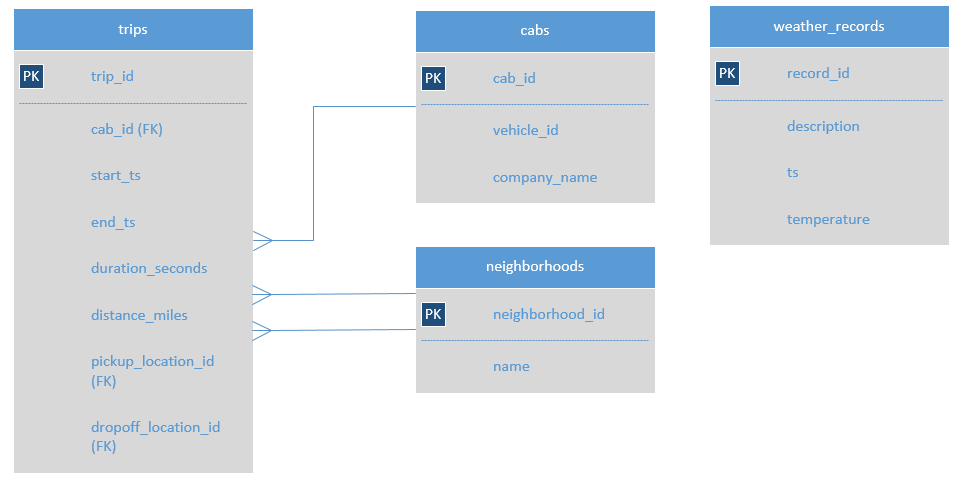

In [1]:
from IPython.display import Image, display
display(Image(filename='/content/moved_Untitled_1_1585510727.png'))


## Obtención de datos meteorológicos mediante Web Scraping

Como parte de la preparación de los datos, se realizó un proceso de extracción de información meteorológica utilizando técnicas de *web scraping*. Para ello, se emplearon las librerías `requests` y `BeautifulSoup`, permitiendo acceder al contenido HTML de una página web que contiene registros históricos del clima en Chicago.

Posteriormente, se identificó la tabla con identificador `weather_records` y se transformó su contenido en un DataFrame de pandas para facilitar su análisis. Este procedimiento permitió obtener una estructura tabular con información meteorológica que posteriormente puede utilizarse para estudiar la relación entre las condiciones climáticas y los patrones de movilidad observados en los viajes.

La incorporación de estos datos resulta especialmente relevante para el proyecto, ya que permitirá evaluar si variables externas, como la lluvia u otras condiciones atmosféricas, influyen en la duración de los desplazamientos realizados por los pasajeros.

In [ ]:
import requests as r
import pandas as pd
from bs4 import BeautifulSoup

URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'
req = r.get(URL)
soup = BeautifulSoup(req.text, 'html.parser')
DataFrame = soup.find('table', attrs = {'id': 'weather_records'})
weather_records = pd.read_html(str(DataFrame))[0]
print(weather_records)

## Extracción de datos para la prueba de hipótesis

Antes de realizar la prueba estadística en Python, se construyó una consulta SQL para obtener los viajes necesarios para el análisis.

La consulta combina información de las tablas `trips` y `weather_records` con el objetivo de analizar la duración de los recorridos realizados entre el barrio **Loop** y el **Aeropuerto Internacional O'Hare** durante los sábados.

Para ello:

- Se seleccionó la fecha y hora de inicio del viaje (`start_ts`).
- Se incluyó la duración del recorrido en segundos (`duration_seconds`).
- Se clasificaron las condiciones climáticas en dos categorías:
  - **Bad**: cuando la descripción meteorológica contiene términos relacionados con lluvia o tormenta.
  - **Good**: para el resto de las condiciones climáticas.
- Se filtraron únicamente los viajes:
  - Con origen en el Loop (`pickup_location_id = 50`).
  - Con destino al Aeropuerto O'Hare (`dropoff_location_id = 63`).
  - Realizados los sábados (`EXTRACT(DOW FROM start_ts) = 6`).

Esta preparación de los datos permitió construir un conjunto de observaciones comparable entre días con clima favorable y desfavorable, proporcionando la información necesaria para evaluar la hipótesis principal del proyecto:

> ¿La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia durante los sábados lluviosos?

Los datos obtenidos servirán posteriormente para aplicar una prueba de hipótesis y determinar si las diferencias observadas en la duración de los recorridos son estadísticamente significativas.

In [ ]:
SELECT
    start_ts,
    T.weather_conditions,
    duration_seconds
FROM
    trips
INNER JOIN (
    SELECT
        ts,
        CASE
            WHEN description LIKE '%rain%' OR description LIKE '%storm%' THEN 'Bad'
            ELSE 'Good'
        END AS weather_conditions
    FROM
        weather_records
) AS T ON T.ts = trips.start_ts
WHERE
    pickup_location_id = 50 AND
    dropoff_location_id = 63 AND
    EXTRACT(DOW FROM start_ts) = 6
ORDER BY
    trip_id;

Carga de librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns

Carga de los datasets

In [ ]:
Taxis = pd.read_csv("/content/moved_project_sql_result_01.csv")
Viajes = pd.read_csv("/content/moved_project_sql_result_04.csv")
Consulta = pd.read_csv("/content/moved_project_sql_result_07.csv")

Información general de los datasets

In [ ]:

Taxis.info()
print()
print()
print()
print()
Viajes.info()
print()
print()
print()
print()
Consulta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   dur

No encontramos valores faltantes

Búsqueda de duplicados explícitos

In [ ]:
print(Taxis.duplicated().sum())
print(Viajes.duplicated().sum())
print(Consulta.duplicated().sum())

0
0
197


En el último dataset de nombre "Consulta" se encontraron 197 duplicados explícitos los cuales se procederan a analizar más a detalle.

In [ ]:
print(Consulta.sample(50))

                 start_ts weather_conditions  duration_seconds
562   2017-11-04 10:00:00               Good            1975.0
965   2017-11-04 08:00:00               Good            1392.0
96    2017-11-11 07:00:00               Good            1200.0
593   2017-11-11 12:00:00               Good            2015.0
658   2017-11-18 12:00:00                Bad            2700.0
370   2017-11-11 09:00:00               Good            1200.0
774   2017-11-11 09:00:00               Good            1316.0
546   2017-11-11 11:00:00               Good            1832.0
380   2017-11-11 07:00:00               Good            1261.0
631   2017-11-18 12:00:00                Bad            2877.0
995   2017-11-11 12:00:00               Good            1500.0
841   2017-11-04 12:00:00               Good            2520.0
922   2017-11-18 08:00:00                Bad            1495.0
567   2017-11-11 12:00:00               Good            2133.0
946   2017-11-04 15:00:00               Good           

Se llegó a la conclusión de que los duplicados explícitos provienen en su mayoria de la colummna "weather_conditions" y tomando en cuenta que en la consulta SQL se colocaron "Bad" o "Good" como condicionales, no se considera como un error, por lo que no los eliminamos.

Procedemos con la verificación de los tipos de datos de los datasets tomando unas muestras de 5 filas por cada dataset.

In [ ]:
print(Taxis.sample(5))
print(Taxis.dtypes)
print()
print()
print()
print()
print(Viajes.sample(5))
print(Viajes.dtypes)
print()
print()
print()
print()
print(Consulta.sample(5))
print(Consulta.dtypes)


                                 company_name  trips_amount
27                   Service Taxi Association           402
33                           Metro Jet Taxi A           146
62  2241 - 44667 - Felman Corp, Manuel Alonso             3
57                                Metro Group            11
29                                   303 Taxi           250
company_name    object
trips_amount     int64
dtype: object




   dropoff_location_name  average_trips
91              Burnside       2.333333
76    Washington Heights       9.133333
46             Chinatown      52.433333
72         South Chicago      13.000000
13                Uptown     849.666667
dropoff_location_name     object
average_trips            float64
dtype: object




                 start_ts weather_conditions  duration_seconds
277   2017-11-18 04:00:00               Good            1737.0
394   2017-11-18 07:00:00                Bad            1322.0
622   2017-11-04 20:00:00               Good            1860.0


Nos dimos cuenta de que en el dataset "Consulta" en la columna ["start_ts"] el tipo de dato es object cuando debería ser de tipo datetime64 por ser una fecha, por lo que procederemos con su conversión y confirmación de cambio.

In [ ]:
Consulta["start_ts"] = pd.to_datetime(Consulta["start_ts"])

print(Consulta.sample(5))
print(Consulta.dtypes)

               start_ts weather_conditions  duration_seconds
642 2017-11-11 12:00:00               Good            1980.0
748 2017-11-04 09:00:00               Good            1843.0
607 2017-11-11 16:00:00               Good            2213.0
524 2017-11-18 08:00:00                Bad            1500.0
363 2017-11-04 07:00:00               Good            1440.0
start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object


Identificación los 10 principales barrios en términos de finalización del recorrido.

In [ ]:
Viajes = Viajes.sort_values(by = "average_trips", ascending = False).copy()
print(Viajes.head(10))

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Dado que el dataframe original tiene 94 filas, procedemos a generar un nuevo dataframe con los 10 barrios principales. Luego confirmaremos la generación de este nuevo dataset.

In [ ]:
principales_viajes = Viajes.iloc[0:10].copy()

principales_viajes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  10 non-null     object 
 1   average_trips          10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes


Graficación de los 10 barrios principales por número de finalizaciones

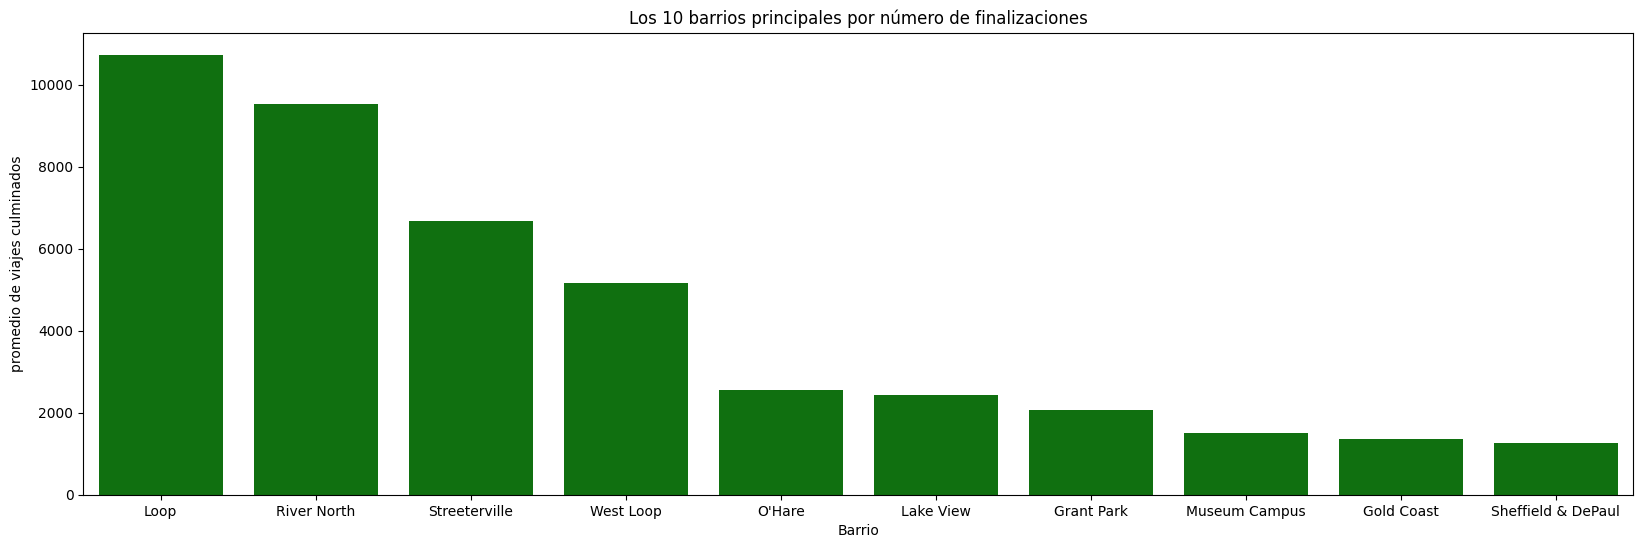

In [ ]:
plt.figure(figsize=(20, 6))

sns.barplot(data = principales_viajes, x = "dropoff_location_name", y = "average_trips", color = "green")

plt.title("Los 10 barrios principales por número de finalizaciones")
plt.xlabel("Barrio")
plt.ylabel("promedio de viajes culminados")
plt.show()

Identificación de las 10 empresas con mayor cantidad de viajes

In [ ]:
Taxis = Taxis.sort_values(by = "trips_amount", ascending = False).copy()

Dado que hemos visto que este dataset contiene 64 filas procederemos a generar un nuevo dataset con las 10 primeras filas que contienen la 10 empresas con mayor cantidad de viajes.

In [ ]:
empresas_viajes = Taxis.iloc[0:10].copy()

empresas_viajes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  10 non-null     object
 1   trips_amount  10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


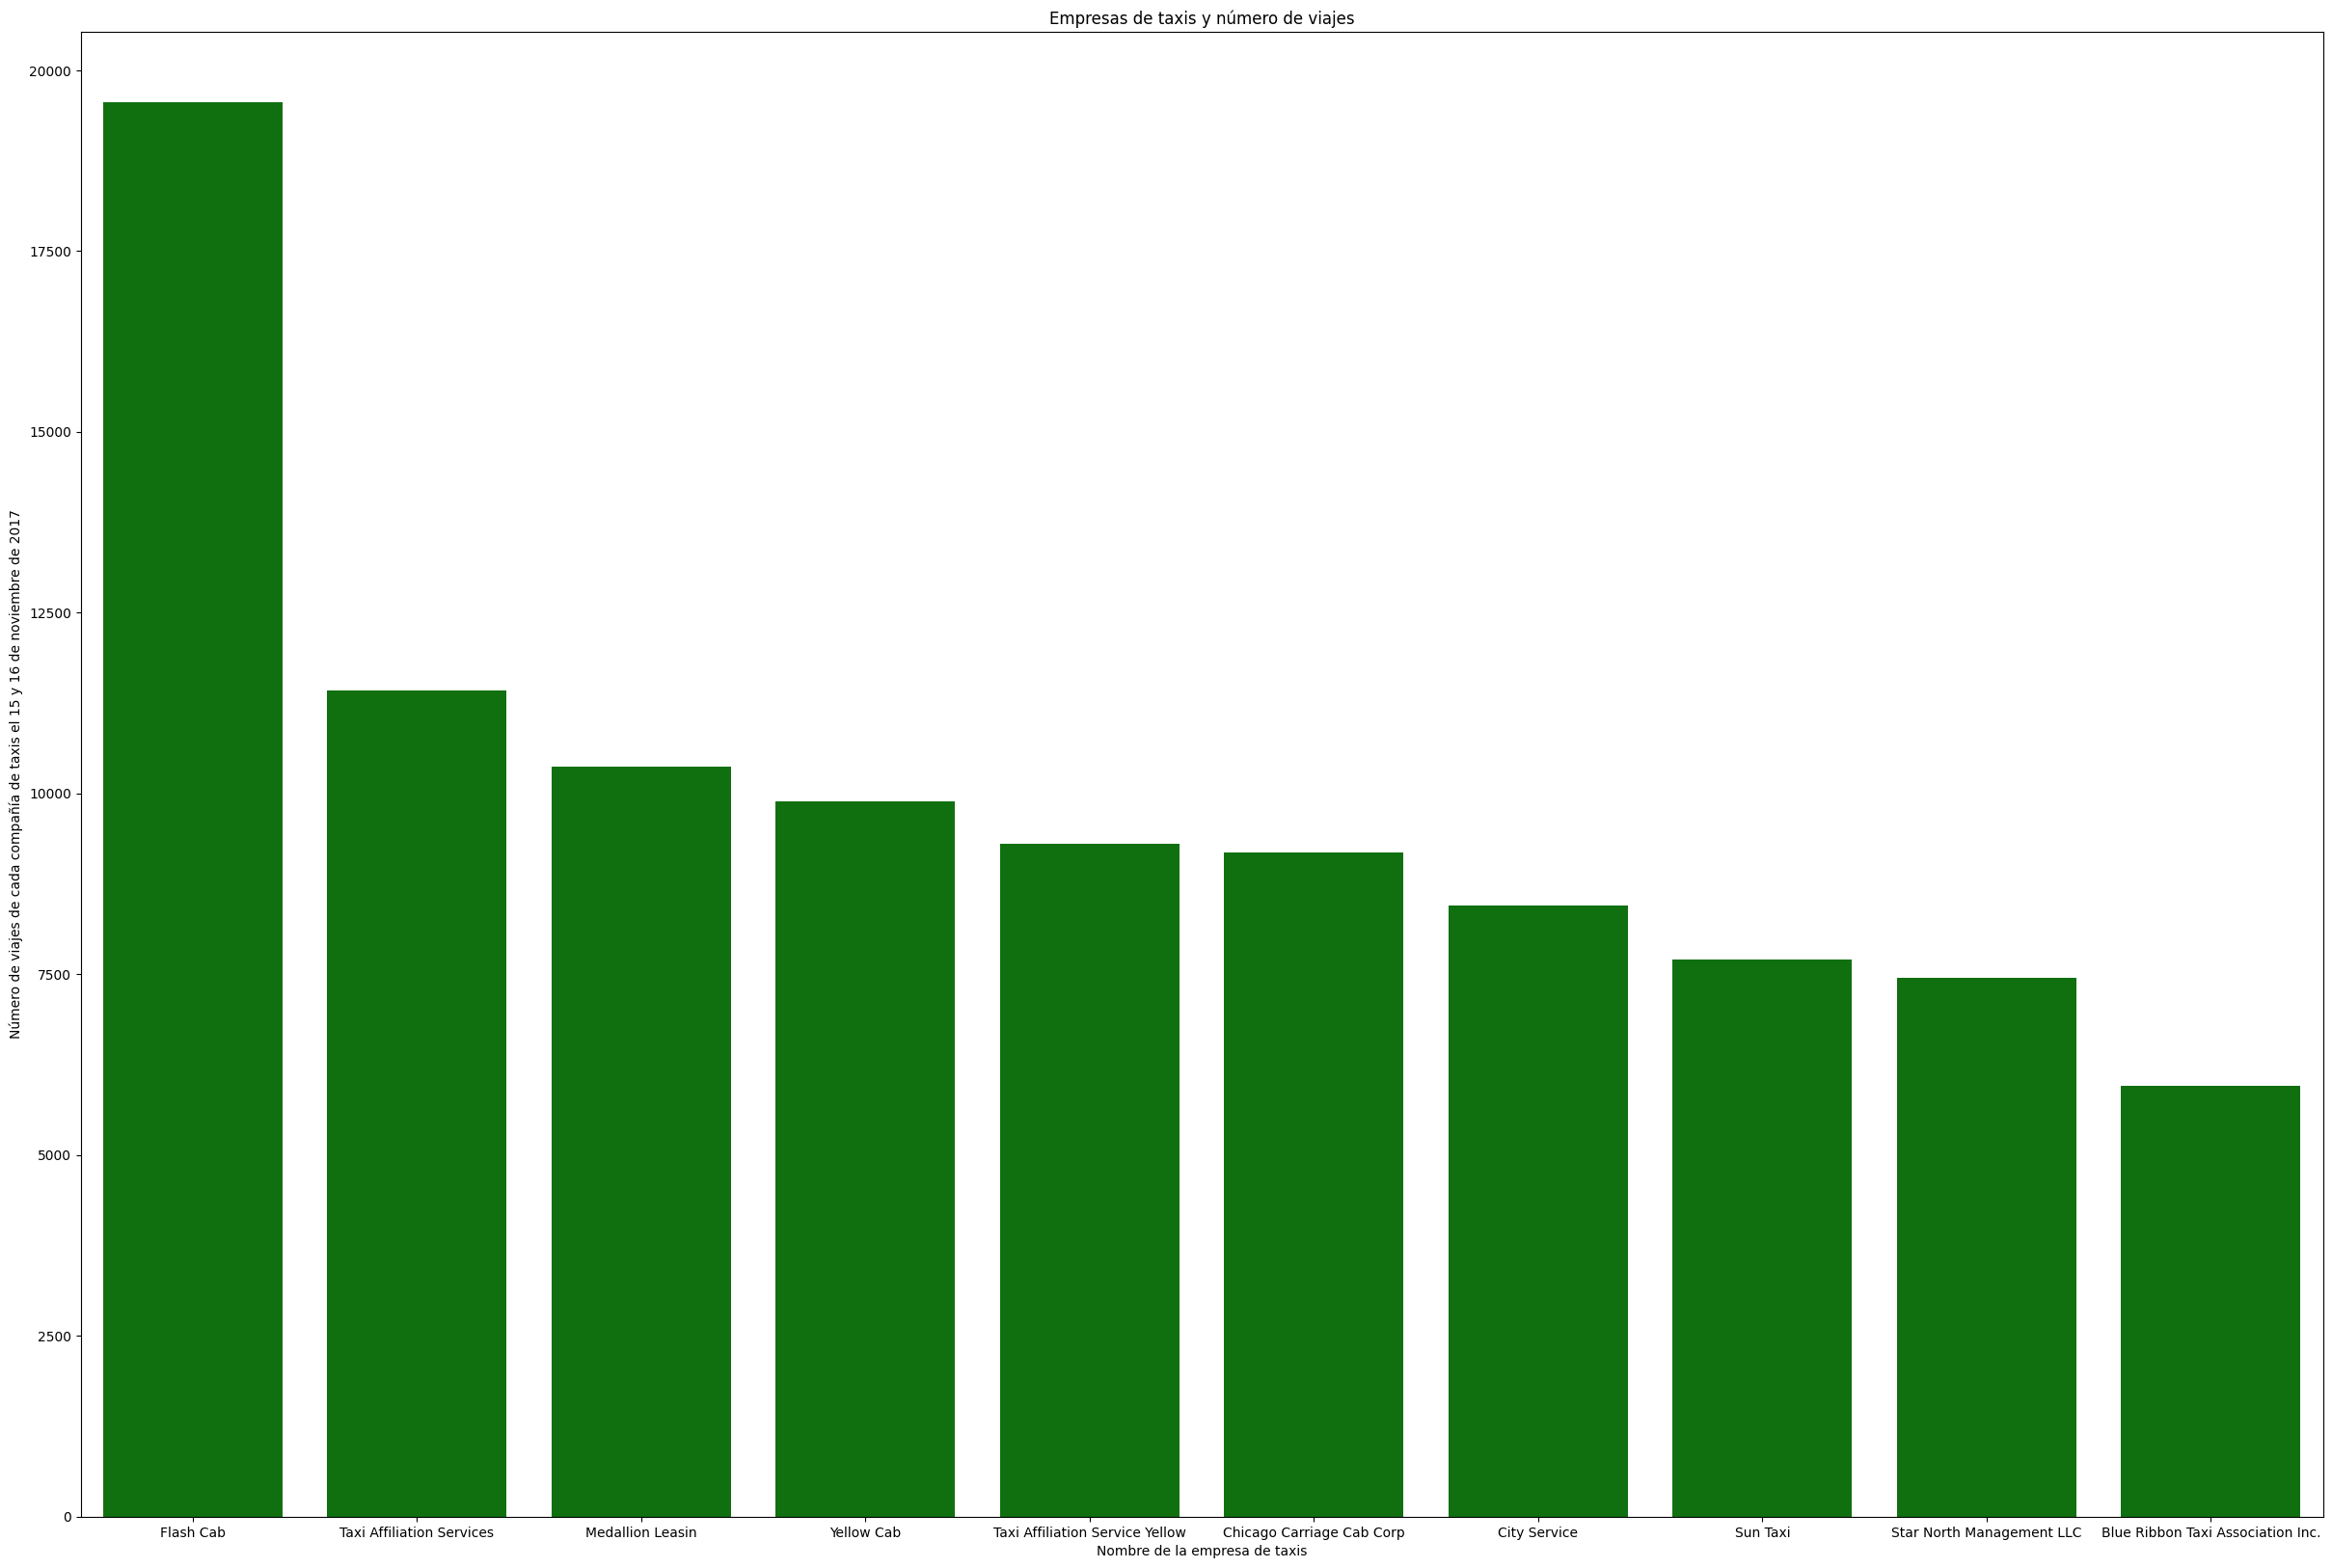

In [ ]:
plt.figure(figsize=(30, 20))

sns.barplot(data = empresas_viajes, x = "company_name", y = "trips_amount", color = "green")

plt.title("Empresas de taxis y número de viajes")
plt.xlabel("Nombre de la empresa de taxis")
plt.ylabel("Número de viajes de cada compañía de taxis el 15 y 16 de noviembre de 2017")
plt.show()

Conclusiones

Analizando tanto los datasets así como las graficas nos podemos dar cuenta que en primer punto la empresa con más viajes realizados es Flash Cab, a partir de Taxi Affiliation Services podemos observar una disminución de la cantidad de viajes la cual no es muy pronunciada, sino hasta la empresa Blue Ribbon Association Inc. siendo la más baja en cantidad de viajes realizados.


De los viajes realizados en los barrios analizados nos pudimos dar cuenta que el barrio con mayor número de finalizaciones es Loop con más de 10.000 viajes finalizados, seguido de River North.

De Loop investigamos un poco y nos dimos cuenta que es el corazón del centro de chicago con lugares emblemáticos como Millennium Park, Chicago Cultural Center, el Art Institute of Chicago, Willis Tower y el Chicago Theatre, lo cual podría explicar la gran cantidad de viajes terminados en su zona.



Procederemos con la Prueba de la hipótesis:

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".




In [ ]:
Consulta_sabados = Consulta[Consulta["start_ts"].dt.day_name() == "Saturday"].copy()
print(Consulta_sabados.info())


In [ ]:
Dias_buenos = Consulta[Consulta["weather_conditions"] == "Good"]["duration_seconds"].copy()

print()
print()

Dias_malos = Consulta[Consulta["weather_conditions"] == "Bad"]["duration_seconds"].copy()


In [ ]:
alpha = 0.05

resultado = stats.ttest_ind(Dias_buenos, Dias_malos)
print(resultado)

if resultado.pvalue < alpha:
    print("Rechazamos H0: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos")
else:
    print("No rechazamos H0: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare no cambia los sábados lluviosos")

TtestResult(statistic=np.float64(-6.946177714041499), pvalue=np.float64(6.517970327099473e-12), df=np.float64(1066.0))
Rechazamos H0: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos


En este caso obtuvimos como valor p = 6.517970327099473e-12 que en notación normal es 0.000000000006517970327099473 lo cual es muy inferior al valor establecido alpha = 0.05

Podemos decir en este momento que rechazamos la hipótesis nula (H0) y llegamos a la conclusión de que si hay un cambio en la cantidad de vaijes realizados en días lluviosos o despejados. Podemos decir que en días lluviosos las vías podrían presentar mayores retrasos y una mayor congestión vehicular. A esto le sumamos el hecho de que este análisis se presenta para un barrio central y muy concurrido como lo es Loop.